# DROID-100 → OSS Lance → Doris

[简体中文](droid100_preview.html) | [English](droid100_preview.en.html) · [中文 Notebook](droid100_end_to_end.ipynb) | [English Notebook](droid100_end_to_end.en.ipynb)

## 从一次抓取失败，到可追溯的训练候选

**一份可以运行、讲解和导出成展示页面的 Notebook。** 每一节都有“输入 → 处理 → 输出”示意图。

- 数据：固定版 `lerobot/droid_100`，100 集、三路相机。
- 加工：SigLIP2 图像 embedding、OSS Lance 和向量索引。
- 分析：Doris `vector_search()`、人工复核、失败分布和训练候选。

> 默认 **preview**：离线展示流程图、源规模与 SQL，不下载模型、不连接 OSS/Doris、不伪造结果。
> 配置好环境后切换 **live**，逐节执行真实流程。需要支持 Lance Catalog 和 Vector Search 的 Doris 构建。


In [1]:
from pathlib import Path
import os
import sys

# Locate the project before importing its shared modules.
PROJECT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                if (p / "pipeline/export_droid.py").is_file()), None)
if PROJECT is None:
    raise RuntimeError("Start Jupyter from the project root or notebooks directory")
sys.path.insert(0, str(PROJECT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT / "work/notebook/matplotlib"))

import json
from getpass import getpass
from uuid import uuid4
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, SVG, Markdown, Code, Video
from dotenv import load_dotenv
from notebooks.demo_support import (
    run_export, connect_doris, run_sql, initialize_doris, load_annotations,
)
load_dotenv(PROJECT / ".env", override=False)

# Change MODE to live only when your OSS and Doris settings are ready.
MODE = "preview"
RUN_EXPORT = False
RUN_SETUP = False
IMPORT_LABELS = False
RESUME_EXPORT = False
DATASET_ROOT = os.getenv("NOTEBOOK_DATASET_ROOT", "oss://YOUR_BUCKET/robotics/droid100")
MAX_EPISODES = 100
FRAME_STRIDE = 15
DEVICE = "auto"
REFERENCE_SAMPLE = "0:observation.images.wrist_image_left:0"
RUN_ID = "nb_" + uuid4().hex[:12]
WORK = PROJECT / "work/notebook"
LABEL_DIR = WORK / "labels"
QUERY_DIR = WORK / "queries" / RUN_ID
LIVE = MODE == "live"
assert MODE in {"preview", "live"}
connection = None
counts = None
hits = pd.DataFrame()
coverage = distribution = reasons = training = pd.DataFrame()
print(f"Mode: {MODE} | run_id: {RUN_ID}")


Mode: preview | run_id: nb_9b6577bfdd1b


In [2]:
display(HTML("""
<style>
.jp-RenderedHTMLCommon h1 {color:#102a43;letter-spacing:-.03em}
.jp-RenderedHTMLCommon h2 {color:#176b87;margin-top:1.8em}
.jp-RenderedHTMLCommon table {font-size:14px}
.jp-OutputArea-output svg, .jp-OutputArea-output img {max-width:100%;height:auto}
.demo-note {padding:14px 18px;background:#eef6ff;border-left:4px solid #2563eb;border-radius:8px;color:#16324f}
</style>
"""))


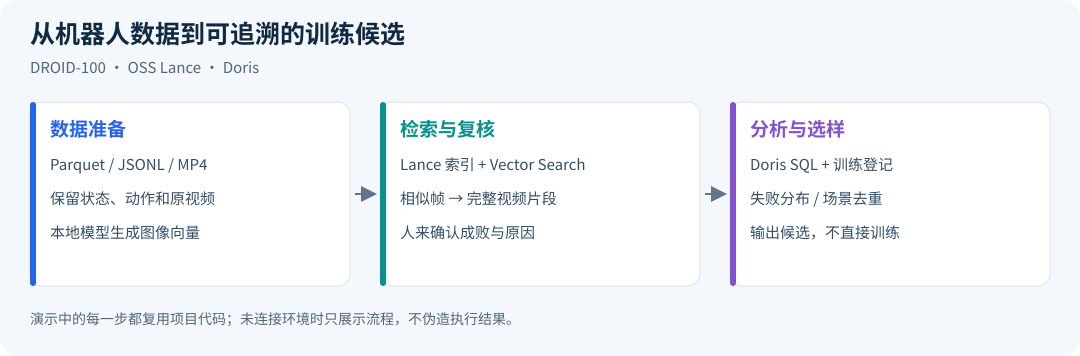

In [3]:
display(SVG(filename=str(PROJECT / "notebooks/assets/00_overview.svg")))


### 运行参数说明

先把项目根目录的 `.env.example` 复制为 `.env`，填写 OSS 和 Doris 连接信息，**密钥不要填进 Notebook**。

| 参数 | 含义 |
|---|---|
| `MODE="preview"` / `"live"` | 离线讲解 / 真实环境运行 |
| `RUN_EXPORT=True` | 调用现有 Python 导出器，实际下载、生成 embedding、写 OSS 并建索引 |
| `RUN_SETUP=True` | 首次创建 Catalog 和三个分析内表；已有环境保持 False |
| `IMPORT_LABELS=True` | 将你填写的两个 CSV 导入 Doris；只导入真实复核和训练登记 |
| `RESUME_EXPORT=True` | 用相同配置恢复已有导出，保留成功索引 |
| `FRAME_STRIDE=15` | 约每秒生成一帧的向量；设为 1 则逐帧处理 |
| `MAX_EPISODES=100` | 默认完整 DROID-100；改为 2 试跑时必须另用输出前缀 |

`RUN_ID` 每次执行配置单元都会更新。人工复核后只重跑“标签导入”及后续单元，保持本次 run_id。
Doris Catalog 的 warehouse 必须与 DATASET_ROOT 一致。原始第 0 帧只用于连通性演示，不宣称它是失败样本。


## 01 / 原始数据是什么，如何导入？

固定 v2.1 commit：`78f887947f976d85dd04594bcbd0b05c29893349`。
每集 Parquet 保存同步状态/动作，三个 MP4 保存三路画面，meta 文件保存任务和 episode 信息。
以下是**源版本规模**，不是本次导出已经完成的计数。


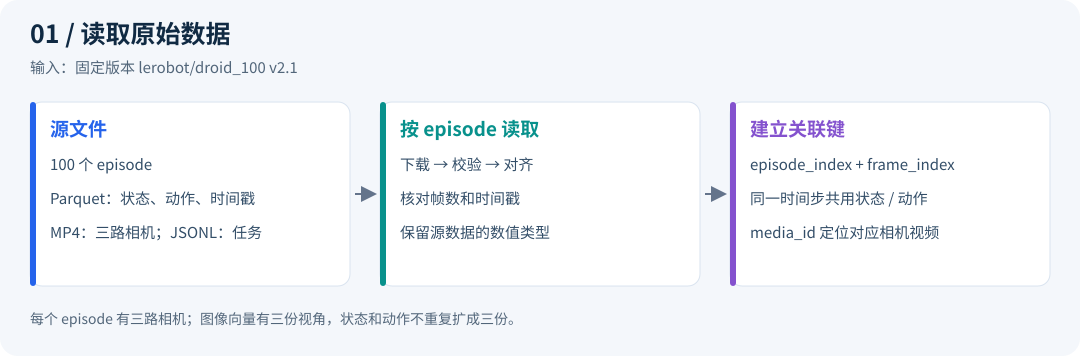

In [4]:
display(SVG(filename=str(PROJECT / "notebooks/assets/01_source.svg")))


In [5]:
source_scale = pd.DataFrame({
    "Source item": ["Episodes", "State/action steps", "Task entries", "MP4 videos",
                    "Frame vectors (stride=1)", "Frame vectors (stride=15)"],
    "Expected count": [100, 32212, 47, 300, 96636, 6591],
})
display(source_scale)


,Source item,Expected count
0,Episodes,100
1,State/action steps,32212
2,Task entries,47
3,MP4 videos,300
4,Frame vectors (stride=1),96636
5,Frame vectors (stride=15),6591


## 02 / 视频如何变成向量？

SigLIP2 对每个采样 RGB 画面生成 768 维向量，在本机 CPU/GPU 推理；不需要在线 embedding API。
`state` 和 `action` 都保留源 7 维数值，不经模型。MP4 原字节也完整保留。
本版本没有音轨，音频表正常为 0 行。视觉相似不能单独表达动作顺序或失败原因。


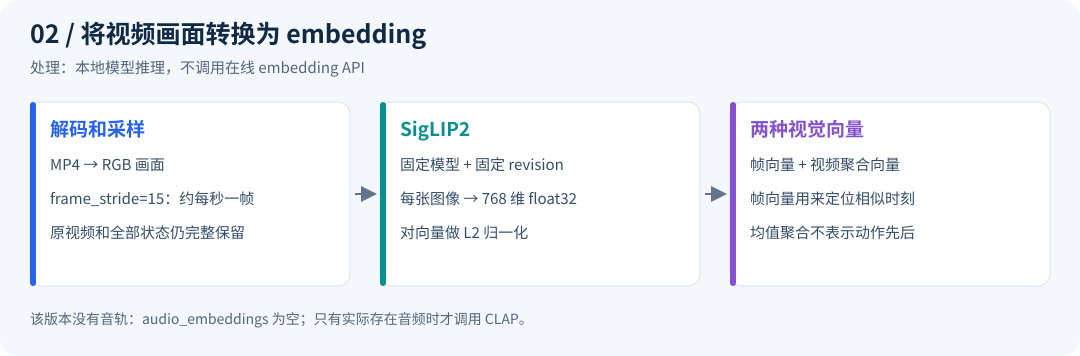

In [6]:
display(SVG(filename=str(PROJECT / "notebooks/assets/02_embedding.svg")))


## 03 / 写入 Lance、构建索引，然后核对结果

这一单元**一次调用现有导出器完成第 01–03 步**，包括真实下载、模型推理、写表和索引。
不在 Notebook 内另造一套导出逻辑。已有完整导出时保持 `RUN_EXPORT=False`，直接读取检查。


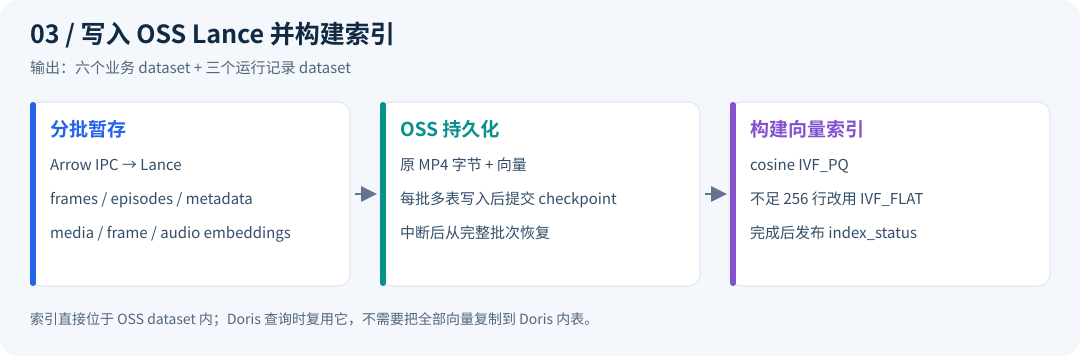

In [7]:
display(SVG(filename=str(PROJECT / "notebooks/assets/03_lance.svg")))


In [8]:
if LIVE:
    if "YOUR_BUCKET" in DATASET_ROOT or not DATASET_ROOT.startswith("oss://"):
        raise ValueError("Set DATASET_ROOT to your real OSS export prefix")
    WORK.mkdir(parents=True, exist_ok=True)
    if RUN_EXPORT:
        run_export(PROJECT, DATASET_ROOT, WORK / "export", MAX_EPISODES,
                   FRAME_STRIDE, DEVICE, RESUME_EXPORT)
    else:
        print("Reading an existing export; the export CLI was not run.")
else:
    print("Preview: download, inference, OSS writes and index construction were not executed.")


Preview: download, inference, OSS writes and index construction were not executed.


In [9]:
if LIVE:
    import lance
    from pipeline.export_droid import storage_options
    options = storage_options(DATASET_ROOT, None, None)
    def dataset(name):
        return lance.dataset(DATASET_ROOT.rstrip("/") + f"/{name}.lance", storage_options=options)
    checkpoint = dataset("export_checkpoints").to_table().to_pylist()
    ready = dataset("export_index_status").to_table().to_pylist()
    if not checkpoint[-1]["complete"] or not ready[0]["complete"]:
        raise RuntimeError("Data and indexes must both be complete")
    names = ["frames", "episodes", "media", "frame_embeddings", "audio_embeddings", "metadata"]
    counts = pd.DataFrame({"Dataset": names, "Actual rows": [dataset(n).count_rows() for n in names]})
    episode_ids = set(dataset("episodes").to_table(columns=["episode_index"])["episode_index"].to_pylist())
    source_manifest = dataset("export_manifest").to_table().to_pylist()[0]["config_json"]
    display(counts)
    display(pd.DataFrame([(f.name, str(f.type)) for f in dataset("frame_embeddings").schema],
                         columns=["Embedding field", "Arrow type"]))
    display(dataset("frames").head(5).to_pandas())
else:
    print("Preview: no exported dataset was read. Live mode shows actual counts and schema here.")


Preview: no exported dataset was read. Live mode shows actual counts and schema here.


## 04 / 连接 Doris，并确认它读取的是同一份 Lance 导出

首次运行可设 `RUN_SETUP=True`，直接从环境配置生成建表语句并执行，不在输出中展示密钥。
已有 Catalog 时保持 False。现有环境如果用了 STS，请先手动配置支持临时凭证的 Catalog。
业务数据仍在 OSS，Doris 内表保存命中列表、复核标签和训练登记。


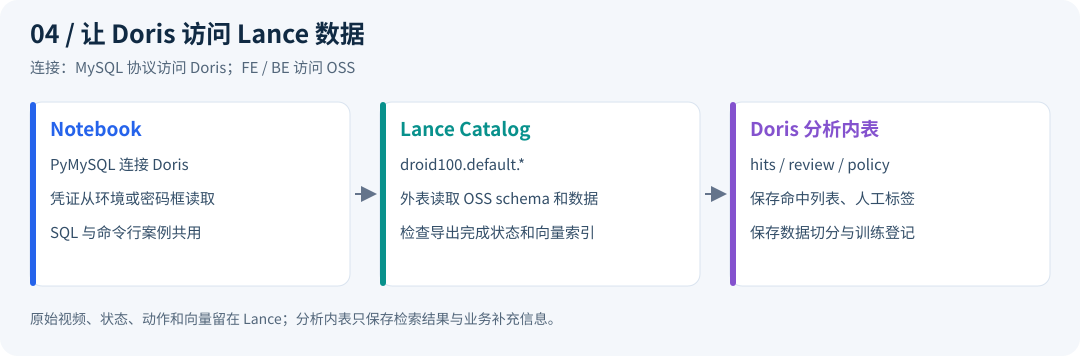

In [10]:
display(SVG(filename=str(PROJECT / "notebooks/assets/04_catalog.svg")))


In [11]:
if LIVE:
    password = os.environ.get("DORIS_PASSWORD")
    if password is None:
        password = getpass("Doris password: ")
    connection = connect_doris(password)
    del password
    if RUN_SETUP:
        setup_results = initialize_doris(connection, PROJECT, DATASET_ROOT)
        print("Initial catalog/table setup completed.")
    db_manifest = run_sql(connection,
        "SELECT config_json FROM droid100.`default`.export_manifest")[0]
    if len(db_manifest) != 1 or db_manifest.iloc[0]["config_json"] != source_manifest:
        raise RuntimeError("The Doris catalog does not match this export manifest")
    display(run_sql(connection, "SHOW INDEX FROM droid100.`default`.frame_embeddings")[0])
else:
    print("Preview: no database connection or DDL was executed.")


Preview: no database connection or DDL was executed.


## 05 / Vector Search：从参考帧搜索相似场景

从已导出的 sample-id 读取真实查询向量，并复用项目的 SQL 模板。相机/模型版本在检索前过滤，
先召回最多 2,000 帧，再按 episode 去重保留最多 50 集。成功与失败都进入候选，形成对照。
下方预览显示模板；live 模式会填入真实的 768 维向量并执行。

现场新图片可先用 `python -m doris.prepare_query --image ...` 生成同模型向量，详见 Doris README。


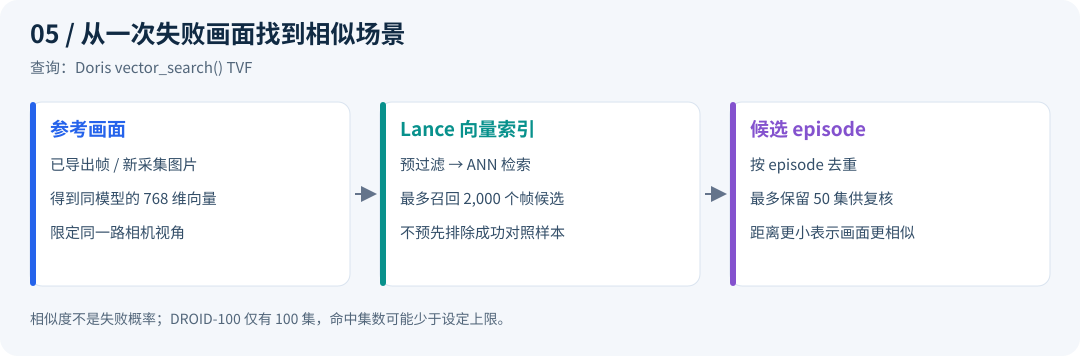

In [12]:
display(SVG(filename=str(PROJECT / "notebooks/assets/05_search.svg")))


In [13]:
display(Code((PROJECT / "doris/sql/02_vector_search.sql").read_text(), language="sql"))


-- Render this template with python -m doris.prepare_query.
-- Vector Search runs in Lance and reuses the cosine index built by the pipeline.
-- Use a new run ID for each query; this INSERT does not delete stale run results.
-- Prefilter before candidate generation; do not prefilter to failure-only rows.
-- Retrieve up to 2000 frames, then deduplicate to at most 50 other episodes.
-- Increase top_k if nearby frames consume too much of the candidate budget.
-- nprobes/refine_factor are example query parameters, not universal optima.
-- 1 - _distance is a display similarity only because metric is cosine.
INSERT INTO internal.droid100_analysis.grasp_hits
SELECT * FROM (
    WITH candidates AS (
        SELECT episode_index, sample_id, media_id, frame_index,
               `timestamp` AS timestamp_s, _distance
        FROM vector_search(
            "table" = "droid100.default.frame_embeddings",
            "column" = "embedding",
            "query_vector" = "{{QUERY_VECTOR_JSON}}",
            "top_k" = "2000",
            "metric" = "cosine",
            "nprobes" = "20",
            "refine_factor" = "10",
            "filter" = "camera = '{{CAMERA}}' AND model = 'google/siglip2-base-patch16-224' AND model_revision = '75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2' AND episode_index >= 0 AND episode_index < 100 AND episode_index != {{REFERENCE_EPISODE}}",
            "use_index" = "true"
        )
    ), ranked AS (
        SELECT *, ROW_NUMBER() OVER (
            PARTITION BY episode_index ORDER BY _distance ASC, frame_index
        ) AS rn
        FROM candidates
    )
    SELECT '{{RUN_ID}}', episode_index, sample_id, media_id,
           frame_index, timestamp_s, 1 - _distance AS similarity
    FROM ranked WHERE rn = 1
    ORDER BY _distance ASC, episode_index LIMIT 50
) candidate_rows;

SHOW INDEX FROM droid100.`default`.frame_embeddings;

In [14]:
if LIVE:
    from doris.prepare_query import read_reference, render
    reference = read_reference(DATASET_ROOT, REFERENCE_SAMPLE, options)
    render(reference, QUERY_DIR, RUN_ID)
    run_sql(connection, (QUERY_DIR / "02_vector_search.sql").read_text())
    with connection.cursor() as cursor:
        cursor.execute("SELECT * FROM internal.droid100_analysis.grasp_hits "
                       "WHERE run_id=%s ORDER BY similarity DESC", (RUN_ID,))
        hits = pd.DataFrame(cursor.fetchall(), columns=[c[0] for c in cursor.description])
    display(hits)
    if not hits.empty:
        fig, ax = plt.subplots(figsize=(10, 3))
        hits.head(15).plot.bar(x="episode_index", y="similarity", ax=ax, color="#2563eb", legend=False)
        ax.set(title="Retrieved episodes: visual similarity", xlabel="Episode", ylabel="Cosine similarity")
        plt.tight_layout()
        plt.show()
else:
    print("Preview: no nearest-neighbor results are fabricated.")


Preview: no nearest-neighbor results are fabricated.


## 06 / 播放视频、查看动作，再导入复核标签

候选帧的 `media_id` 找视频，`episode_index + frame_index` 找状态和动作。
先查看前后时间窗，再回看完整的一次抓取尝试，记录成败、原因、质量与片段边界。
不能把 `next.reward` / `next.done` 自动当作抓取结果。


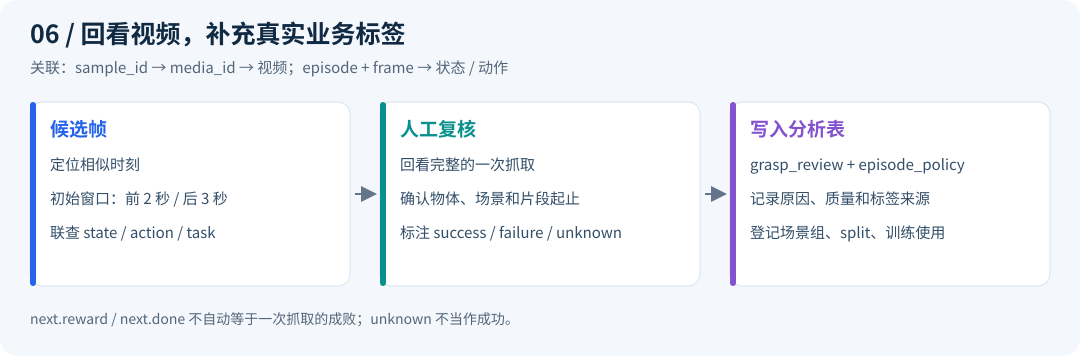

In [15]:
display(SVG(filename=str(PROJECT / "notebooks/assets/06_review.svg")))


In [16]:
if LIVE:
    review_results = run_sql(connection, (QUERY_DIR / "03_review_clips.sql").read_text())
    display(review_results[0])
    display(review_results[1].head(30))
    if not hits.empty:
        import av
        from pipeline.export_media import extract
        # Change this row number to inspect a different retrieved episode.
        selected = hits.iloc[0]
        media_id = str(selected["media_id"])
        video_path = WORK / "media" / (media_id.replace(":", "_") + ".mp4")
        if not video_path.exists():
            extract(DATASET_ROOT, media_id, video_path, options)
        # Decode a still even when the browser cannot play the source AV1 codec.
        with av.open(str(video_path)) as container:
            for number, frame in enumerate(container.decode(video=0)):
                if number == int(selected["frame_index"]):
                    display(frame.to_image())
                    break
        display(Video(filename=str(video_path), embed=True, width=640))
        print(f"Media: {media_id}; inspect the complete attempt before assigning labels.")
else:
    print("Preview: video and action rows appear after a real search.")


Preview: video and action rows appear after a real search.


### 补充两份真实业务数据

填写 `work/notebook/labels/grasp_review.csv` 和 `episode_policy.csv`（首次运行下面单元会复制空模板）。
`grasp_review` 的 run_id、sample_id、episode_index 必须对应本次检索；outcome 只能是
success / failure / unknown。`episode_policy` 应覆盖**所有已导出的 episode**，包括验证/测试集。
字段规则见 `doris/README.zh-CN.md`。没有标签时仍可演示检索，但不能计算有效失败比例。

填写完后将配置中的 `IMPORT_LABELS` 单独设为 True，再从本单元继续执行；不要重跑生成新 RUN_ID 的配置单元。
也可以直接执行一个新单元 `IMPORT_LABELS = True`，保持当前检索不变。


In [17]:
if LIVE:
    import shutil
    LABEL_DIR.mkdir(parents=True, exist_ok=True)
    for name in ("grasp_review.csv", "episode_policy.csv"):
        target = LABEL_DIR / name
        if not target.exists():
            shutil.copyfile(PROJECT / "doris/templates" / name, target)
    print(f"Current review run: {RUN_ID}")
    if IMPORT_LABELS:
        imported = load_annotations(connection, PROJECT, LABEL_DIR / "grasp_review.csv",
                                    LABEL_DIR / "episode_policy.csv", RUN_ID, hits, episode_ids)
        display(pd.DataFrame(imported.items(), columns=["Table", "Imported rows"]))
    else:
        print("Label import skipped. Fill the CSVs, set IMPORT_LABELS=True, and rerun this cell.")
else:
    print("Preview: label templates remain empty; no outcomes are invented.")


Preview: label templates remain empty; no outcomes are invented.


## 07 / 失败集中在哪里？

先展示标签覆盖率，再按物体/场景统计失败比例，最后按阶段和原因看失败分布。
分母仅包含“已复核、质量可用、属于目标任务、成败已知”的尝试。
结果描述本次相似检索样本群，不能外推成机器人线上总体失败率。


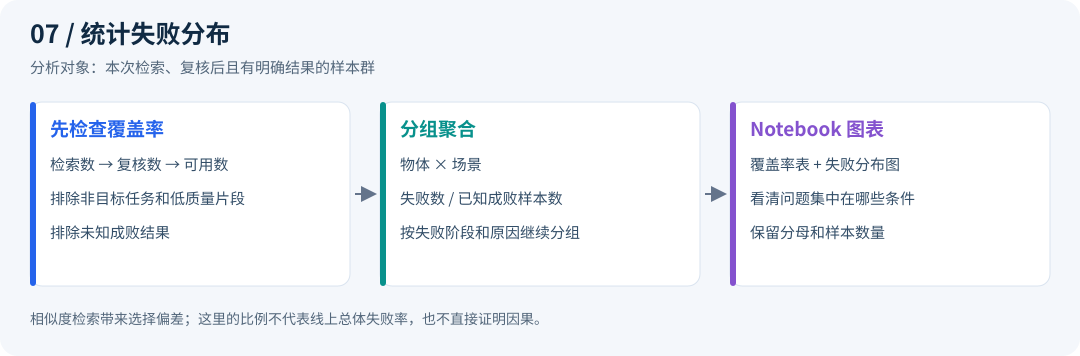

In [18]:
display(SVG(filename=str(PROJECT / "notebooks/assets/07_analysis.svg")))


In [19]:
if LIVE:
    coverage, distribution, reasons = run_sql(connection, (QUERY_DIR / "04_failure_distribution.sql").read_text())
    display(coverage)
    display(distribution)
    display(reasons)
    if distribution.empty:
        print("No eligible known outcomes. Review clips and import labels before interpreting failure rates.")
    else:
        view = distribution.copy()
        for field in ("failure_pct", "reviewed_known_clips", "failed_clips"):
            view[field] = pd.to_numeric(view[field], errors="raise")
        view["Group"] = view["object_type"].fillna("unknown") + " / " + view["scene_type"].fillna("unknown")
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        view.plot.barh(x="Group", y="failure_pct", ax=axes[0], color="#d97706", legend=False)
        axes[0].set(title="Failure rate within reviewed cohort", xlabel="Failure (%)", ylabel="Object / scene", xlim=(0, 100))
        view.plot.barh(x="Group", y=["reviewed_known_clips", "failed_clips"], ax=axes[1], color=["#08918c", "#d97706"])
        axes[1].set(title="Always inspect the denominator", xlabel="Reviewed attempts", ylabel="")
        plt.tight_layout()
        plt.show()
else:
    print("Preview: failure charts require real review labels; no percentages are synthesized.")


Preview: failure charts require real review labels; no percentages are synthesized.


## 08 / 选出值得补充训练的样本

排除未知训练登记、已训练、质量差、片段边界无效、非训练集及跨 split 的场景组。
同一物体/场景/用途桶按场景组去重，最多保留 20 条。
成功片段用于行为克隆正例；失败片段用于诊断或 critic 候选，不直接作为正确动作目标。


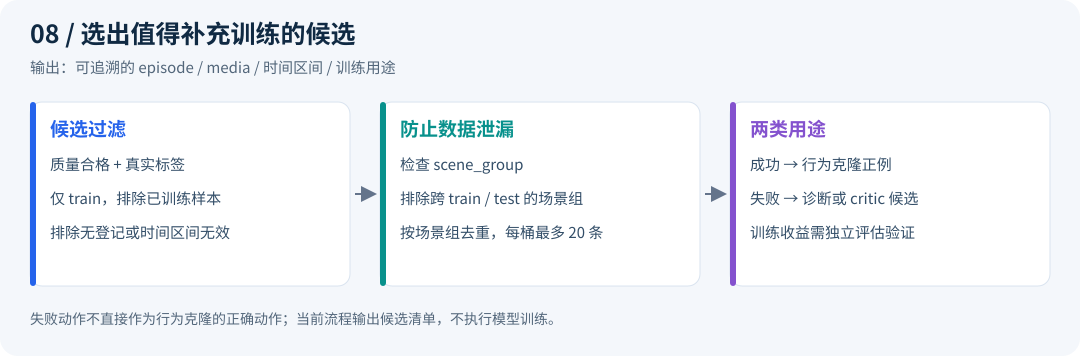

In [20]:
display(SVG(filename=str(PROJECT / "notebooks/assets/08_training.svg")))


In [21]:
if LIVE:
    mixed_groups, training = run_sql(connection, (QUERY_DIR / "05_select_training_samples.sql").read_text())
    display(mixed_groups)
    display(training)
    if not mixed_groups.empty:
        print("Mixed-split groups were excluded. Correct the group registry before training.")
    if training.empty:
        print("No eligible candidates. Inspect review coverage and the complete episode policy.")
    else:
        target = QUERY_DIR / "training_candidates.csv"
        training.to_csv(target, index=False)
        print(f"Saved {len(training)} training candidates to {target}")
    report_dir = QUERY_DIR / "report"
    report_dir.mkdir(parents=True, exist_ok=True)
    for name, table in {"hits": hits, "coverage": coverage, "failure_distribution": distribution,
                        "failure_reasons": reasons, "training_candidates": training}.items():
        table.to_csv(report_dir / f"{name}.csv", index=False)
else:
    print("Preview: this section defines selection rules; it does not claim training results.")


Preview: this section defines selection rules; it does not claim training results.


## 把 Notebook 作为展示页面

**现场演示**：在 JupyterLab 中运行，折叠代码，展示每步示意图、视频、表格和图表。

**分享静态页面**：保存已执行 Notebook 后，在项目根目录运行：

```bash
jupyter nbconvert notebooks/droid100_end_to_end.ipynb \
  --to html --no-input --embed-images --output-dir work/presentation
```

HTML 可以直接用浏览器打开，不需要观看者安装 Python。已保存的图表和嵌入视频会随页面保留，
但 HTML 不会重新执行 Python/SQL。live 输出未执行或未保存时，页面里也不会出现真实分析结果。
共享前检查页面里的视频、业务数据与错误输出；隐藏代码不等于清除输出中的敏感信息。

项目附带 `droid100_preview.html` 是 **preview 模式实跑的流程讲解页**，并非一次 OSS/Doris 执行报告。

官方资料：[nbconvert HTML 导出](https://nbconvert.readthedocs.io/en/latest/usage.html)
· [Doris Lance Catalog / Vector Search](https://doris.apache.org/docs/4.x/lakehouse/catalogs/lance-catalog/)

更新两种语言的展示页并保留相对切换链接：保存两份 Notebook 后，运行 `python -m notebooks.export_presentations`。
分享时将两份生成的 HTML 放在同一目录；该工具只导出已保存输出，不执行单元。


In [22]:
if connection is not None:
    connection.close()
    connection = None
print("Session finished. Reconnect at step 04 before running more database queries.")


Session finished. Reconnect at step 04 before running more database queries.
